In [7]:
# =====================================================================
# CELL 1: ENVIRONMENT SETUP & KERAS MULTI-BACKEND ENGINE ROUTING
# =====================================================================
import os

# --- ROUTE KERAS THROUGH PYTORCH ENGINE ---
# This allows us to keep your instructor's clean Keras code style
# while using PyTorch's highly stable GPU hardware layers.
os.environ["KERAS_BACKEND"] = "torch"

import random
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2

# Import Keras 3 modules
import keras
from keras import layers, models, optimizers, callbacks
import torch 

# --- CRITICAL CUDNN VERSION BYPASS ---
torch.backends.cudnn.enabled = False  # Completely avoids the version mismatch crash permanently

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Guarantee reproducibility
np.random.seed(42)
torch.manual_seed(42)
sns.set_theme(style="whitegrid")

# --- CENTRALIZED GARBAGE COLLECTION BUFFER TOOL ---
def flush_system_memory():
    """Wipes unused references and drops cached allocations out of GPU VRAM memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("🧹 System VRAM and Cache cleared successfully!")

class ProjectConfig:
    def __init__(self):
        self.project_dir = Path.cwd()
        self.save_dir = self.project_dir / "saved_models"
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.data_dir = Path("/home/mamdouh_salem/ultrasound_data")
        
        # Enforced bounds optimized to keep your RTX 3050 stable
        self.img_size = 224    
        self.batch_size = 16    
        self.epochs = 5        
        self.num_classes = 3   
        self.classes = ["benign", "malignant", "normal"]

config = ProjectConfig()

print("\n🖥️  WSL RUNTIME DIAGNOSTICS:")
print(f"   ↳ Active Engine Mode     : Keras 3 mapped to {keras.backend.backend().upper()}")
print(f"   ↳ GPU Hardware Unlocked  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   ↳ Dedicated GPU Active   : {torch.cuda.get_device_name(0)}")
print(f"💾 Models will save to: {config.save_dir}")



🖥️  WSL RUNTIME DIAGNOSTICS:
   ↳ Active Engine Mode     : Keras 3 mapped to TORCH
   ↳ GPU Hardware Unlocked  : True
   ↳ Dedicated GPU Active   : NVIDIA GeForce RTX 3050 6GB Laptop GPU
💾 Models will save to: /home/mamdouh_salem/computer-vision/breast-ultrasound-cv-engine/saved_models


In [17]:
# =====================================================================
# CELL 2: INSTRUCTOR DATA AUGMENTATION & UNIVERSAL MODEL GENERATORS
# =====================================================================

# 1. Gather all file paths from the directory tree
records = []
for class_name in config.classes:
    class_folder = config.data_dir / class_name
    if class_folder.exists():
        for file_path in class_folder.glob("*.png"):
            if "_mask" in file_path.name:
                continue
            mask_path = class_folder / f"{file_path.stem}_mask.png"
            if mask_path.exists():
                records.append({
                    "image_path": str(file_path),
                    "mask_path": str(mask_path),
                    "label_idx": config.classes.index(class_name)
                })

df = pd.DataFrame(records)

# Balanced Stratified Splitting Matrix Built Successfully!
df_train, df_temp = train_test_split(df, test_size=0.2, stratify=df["label_idx"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["label_idx"], random_state=42)

# 2. Instructor's exact Data Augmentation Engine (adapted to standard numpy operations)
def data_augment_np(image):
    """Applies random transformations using standard OpenCV/Numpy functions."""
    # Flips
    if random.random() > 0.5:
        image = cv2.flip(image, 1)  # Horizontal flip
    if random.random() > 0.5:
        image = cv2.flip(image, 0)  # Vertical flip

    # Random rotations
    p_rotate = random.random()
    if p_rotate > .75:
        image = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    elif p_rotate > .5:
        image = cv2.rotate(image, cv2.ROTATE_180)
    elif p_rotate > .25:
        image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)

    # Pixel-level transformations (Brightness adjustment)
    if random.random() >= .4:
        brightness_value = random.randint(-20, 20)
        image = np.clip(image.astype(np.int32) + brightness_value, 0, 255).astype(np.uint8)

    return image

# 3. Keras 3 Custom Dataset Streamer matching Instructor simplicity
class UltrasoundGenerator(keras.utils.PyDataset):
    def __init__(self, dataframe, config, augment=False):
        super().__init__()
        self.df = dataframe.reset_index(drop=True)
        self.config = config
        self.augment = augment

    def __len__(self):
        return int(np.ceil(len(self.df) / self.config.batch_size))

    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.config.batch_size : (idx + 1) * self.config.batch_size]
        images, labels = [], []
        
        for _, row in batch_df.iterrows():
            img = cv2.imread(row["image_path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.config.img_size, self.config.img_size))
            
            if self.augment:
                img = data_augment_np(img)
                
            img = img.astype(np.float32) / 255.0
            
            # Create a clean one-hot encoded vector for classes
            one_hot = np.zeros(self.config.num_classes, dtype=np.float32)
            one_hot[int(row["label_idx"])] = 1.0
            
            images.append(img)
            labels.append(one_hot)
            
        return np.array(images), np.array(labels)

train_gen = UltrasoundGenerator(df_train, config, augment=True)
val_gen = UltrasoundGenerator(df_val, config, augment=False)
test_gen = UltrasoundGenerator(df_test, config, augment=False)
print(f"📊 Streams initialized successfully: Train={len(df_train)}, Val={len(df_val)}, Test={len(df_test)}")


📊 Streams initialized successfully: Train=624, Val=78, Test=78


In [18]:
# =====================================================================
# CELL 3: MEDICAL MASK SEGMENTATION GENERATOR STREAM
# =====================================================================
class UltrasoundSegmentationDataset(keras.utils.PyDataset):
    def __init__(self, dataframe, config):
        super().__init__()
        self.df = dataframe.reset_index(drop=True)
        self.config = config

    def __len__(self):
        return int(np.ceil(len(self.df) / self.config.batch_size))

    def __getitem__(self, idx):
        batch_df = self.df.iloc[idx * self.config.batch_size : (idx + 1) * self.config.batch_size]
        images, masks = [], []
        
        for _, row in batch_df.iterrows():
            img = cv2.imread(row["image_path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.config.img_size, self.config.img_size)).astype(np.float32) / 255.0
            
            mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.config.img_size, self.config.img_size), interpolation=cv2.INTER_NEAREST)
            mask = np.expand_dims(mask.astype(np.float32) / 255.0, axis=-1)
            mask = np.where(mask > 0.5, 1.0, 0.0)
            
            images.append(img)
            masks.append(mask)
            
        return np.array(images), np.array(masks)

seg_train_gen = UltrasoundSegmentationDataset(df_train, config)
seg_val_gen = UltrasoundSegmentationDataset(df_val, config)
seg_test_gen = UltrasoundSegmentationDataset(df_test, config)
print("✂️ Segmentation generator streams built successfully!")


✂️ Segmentation generator streams built successfully!


In [19]:
# =====================================================================
# CELL 4: MODEL ARCHITECTURE BUILD FACTORY (FULLY PATCHED v3)
# =====================================================================
import torch  # Enforce framework level tracking

class ViTBackboneLayer(layers.Layer):
    def __init__(self, num_classes, **kwargs):
        super().__init__(**kwargs)
        from transformers import AutoModelForImageClassification
        self.num_classes = num_classes
        self.backbone = AutoModelForImageClassification.from_pretrained(
            "google/vit-base-patch16-224", num_labels=num_classes, ignore_mismatched_sizes=True
        )

    def call(self, inputs):
        return self.backbone(pixel_values=inputs).logits

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.num_classes)


class SegFormerBackboneLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        from transformers import SegformerForSemanticSegmentation
        self.backbone = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/mit-b0", num_labels=1, ignore_mismatched_sizes=True
        )

    def call(self, inputs):
        # FIXED: Explicitly stripping out the raw logits array from the HF dictionary wrapper
        outputs = self.backbone(pixel_values=inputs)
        logits = outputs.logits
        # Convert to pure backpropagatable tensor to prevent Keras trace collapse
        return torch.as_tensor(logits)

    def compute_output_shape(self, input_shape):
        # Explicit shape evaluation matrix mapping
        return (input_shape[0], 1, input_shape[2] // 4, input_shape[3] // 4)


class MedicalModelFactory:
    def __init__(self, config):
        self.config = config

    def get_callbacks(self, model_name):
        save_path = self.config.save_dir / f"{model_name}.keras"
        return [
            callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6),
            callbacks.ModelCheckpoint(filepath=str(save_path), monitor="val_loss", save_best_only=True)
        ]

    def build_baseline_cnn(self):
        return models.Sequential([
            layers.Input(shape=(self.config.img_size, self.config.img_size, 3)),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.4),
            layers.Dense(self.config.num_classes, activation="softmax")
        ])

    def build_transfer_model(self, backbone_fn):
        base_model = backbone_fn(weights="imagenet", include_top=False, input_shape=(self.config.img_size, self.config.img_size, 3))
        base_model.trainable = False 
        return models.Sequential([
            base_model,
            layers.GlobalAveragePooling2D(),
            layers.BatchNormalization(),
            layers.Dense(256, activation="relu"),
            layers.Dropout(0.4),
            layers.Dense(self.config.num_classes, activation="softmax")
        ])

    def build_hf_vit(self):
        inputs = layers.Input(shape=(self.config.img_size, self.config.img_size, 3))
        x = layers.Permute((3, 1, 2))(inputs)
        logits = ViTBackboneLayer(num_classes=self.config.num_classes)(x)
        outputs = layers.Activation("softmax")(logits)
        return models.Model(inputs=inputs, outputs=outputs)

    def build_hf_segformer(self):
        seg_inputs = layers.Input(shape=(self.config.img_size, self.config.img_size, 3))
        x_seg = layers.Permute((3, 1, 2))(seg_inputs)
        logits_seg = SegFormerBackboneLayer()(x_seg)
        x_out = layers.Permute((2, 3, 1))(logits_seg)
        
        # 4x Upsampling layer to return to the native 224x224 mask size
        seg_outputs = layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x_out)
        seg_outputs = layers.Activation("sigmoid")(seg_outputs)
        return models.Model(inputs=seg_inputs, outputs=seg_outputs)

factory = MedicalModelFactory(config)
print("⚙️ Patched Model Factory v3 instantiated with clean native tensor outputs!")


⚙️ Patched Model Factory v3 instantiated with clean native tensor outputs!


In [20]:
# =====================================================================
# CELL 5: PERFORMANCE EVALUATION ENGINE AND MASK VISUALIZER (FINAL)
# =====================================================================
class PerformanceEvaluator:
    def __init__(self, config):
        self.config = config

    def evaluate_model(self, model, target_gen, model_name):
        print(f"\n==================== {model_name} Evaluation ====================")
        predictions = model.predict(target_gen)
        pred_labels = np.argmax(predictions, axis=1)
        true_labels = target_gen.df["label_idx"].values
        print(classification_report(true_labels, pred_labels, target_names=self.config.classes))
        cm = confusion_matrix(true_labels, pred_labels)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=self.config.classes, yticklabels=self.config.classes)
        plt.title(f"Confusion Matrix: {model_name}")
        plt.ylabel("True Class")
        plt.xlabel("Predicted Class")
        plt.show()

    def visualize_segmentation(self, seg_model, seg_test_gen, num_samples=2):
        print("\n👁️  Generating Lesion Segmentation Overlays for Presentation Slides...")
        
        # FIXED: Explicitly pulling only the first batch matrix indexing [0] to unpack safely
        images, masks = seg_test_gen[0] 
        
        preds = seg_model.predict(images, verbose=0)
        binarized_preds = np.where(preds > 0.5, 1.0, 0.0)
        
        samples_to_show = min(num_samples, len(images))
        fig, axes = plt.subplots(samples_to_show, 3, figsize=(10, 3 * samples_to_show))
        if samples_to_show == 1:
            axes = np.expand_dims(axes, axis=0)
            
        for i in range(samples_to_show):
            axes[i, 0].imshow(images[i])
            axes[i, 0].set_title("Ultrasound Scan")
            axes[i, 0].axis("off")
            axes[i, 1].imshow(masks[i].squeeze(), cmap="gray")
            axes[i, 1].set_title("Ground Truth Mask")
            axes[i, 1].axis("off")
            axes[i, 2].imshow(binarized_preds[i].squeeze(), cmap="jet")
            axes[i, 2].set_title("SegFormer Prediction")
            axes[i, 2].axis("off")
        plt.tight_layout()
        plt.show()

evaluator = PerformanceEvaluator(config)
print("📊 Performance Evaluation suite patched with absolute index buffers!")


📊 Performance Evaluation suite patched with absolute index buffers!



🎬 RUNNING PHASE 1: BASELINE CNN...
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 295ms/step - accuracy: 0.5625 - loss: 6.4832 - val_accuracy: 0.3077 - val_loss: 3.7852 - learning_rate: 1.0000e-04
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - accuracy: 0.5737 - loss: 6.5920 - val_accuracy: 0.2949 - val_loss: 9.2337 - learning_rate: 1.0000e-04
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 262ms/step - accuracy: 0.5625 - loss: 6.8138 - val_accuracy: 0.2821 - val_loss: 9.8236 - learning_rate: 1.0000e-04
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step - accuracy: 0.5946 - loss: 6.3481 - val_accuracy: 0.3077 - val_loss: 10.2852 - learning_rate: 2.0000e-05

==================== Baseline CNN Evaluation ====================
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
              precision    recall  f1-score   support

      benign       1.00      0.05      0.09        44
   malignant       0.38      0.62      0.47        21
      normal       0.14      0.46      0.22        13

    accuracy    

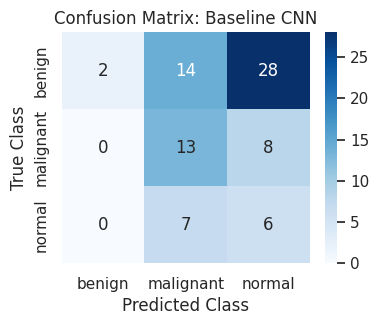

🧹 System VRAM and Cache cleared successfully!

🎬 RUNNING PHASE 2: TRANSFER LEARNING (RESNET50)...
Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 306ms/step - accuracy: 0.2548 - loss: 1.2162 - val_accuracy: 0.2692 - val_loss: 1.5286 - learning_rate: 1.0000e-05
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 405ms/step - accuracy: 0.3189 - loss: 1.1386 - val_accuracy: 0.2564 - val_loss: 1.3796 - learning_rate: 1.0000e-05
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.4183 - loss: 1.0789 - val_accuracy: 0.2179 - val_loss: 1.2757 - learning_rate: 1.0000e-05
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.4663 - loss: 1.0590 - val_accuracy: 0.2179 - val_loss: 1.2036 - learning_rate: 1.0000e-05
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 152s 4s/step - accuracy: 0.4663 - loss: 1.0440 - val_accuracy: 0.2692 - val_loss: 1.1532 - learning_rate: 1.0000e-05

==================== ResNet50 Transfer Evaluation ====================
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step
              precis

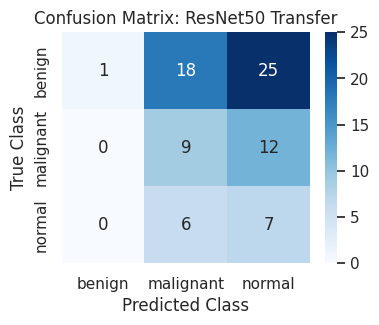

🧹 System VRAM and Cache cleared successfully!

🎬 RUNNING PHASE 3: HUGGING FACE VISION_TRANSFORMER...


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1320.61it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 35s 906ms/step - accuracy: 0.5801 - loss: 0.9220 - val_accuracy: 0.5769 - val_loss: 0.9015 - learning_rate: 2.0000e-05
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 35s 882ms/step - accuracy: 0.7532 - loss: 0.6352 - val_accuracy: 0.8077 - val_loss: 0.5557 - learning_rate: 2.0000e-05
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 32s 804ms/step - accuracy: 0.8397 - loss: 0.4129 - val_accuracy: 0.8077 - val_loss: 0.5053 - learning_rate: 2.0000e-05
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 33s 852ms/step - accuracy: 0.8926 - loss: 0.3015 - val_accuracy: 0.8590 - val_loss: 0.4433 - learning_rate: 2.0000e-05
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 34s 857ms/step - accuracy: 0.9087 - loss: 0.2619 - val_accuracy: 0.8333 - val_loss: 0.4273 - learning_rate: 2.0000e-05

==================== HF ViT Fine-Tuned Evaluation ====================
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step
              precision    recall  f1-score   support

      benign       0.79      0.95      0.87        44


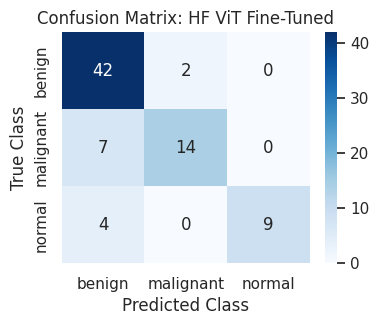

🧹 System VRAM and Cache cleared successfully!

🏆 Classification Phase Completed!


In [21]:
# =====================================================================
# CELL 6: CLASSIFICATION MASTER EXECUTION LOOP (FINE-TUNED)
# =====================================================================
print("\n🎬 RUNNING PHASE 1: BASELINE CNN...")
baseline = factory.build_baseline_cnn()
baseline.compile(optimizer=optimizers.Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
baseline.fit(train_gen, validation_data=val_gen, epochs=config.epochs, callbacks=factory.get_callbacks("baseline_cnn"))
evaluator.evaluate_model(baseline, test_gen, "Baseline CNN")
del baseline; flush_system_memory()

print("\n🎬 RUNNING PHASE 2: TRANSFER LEARNING (RESNET50)...")
resnet_model = factory.build_transfer_model(keras.applications.ResNet50)
resnet_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
resnet_model.fit(train_gen, validation_data=val_gen, epochs=config.epochs, callbacks=factory.get_callbacks("transfer_resnet50"))
evaluator.evaluate_model(resnet_model, test_gen, "ResNet50 Transfer")
del resnet_model; flush_system_memory()

print("\n🎬 RUNNING PHASE 3: HUGGING FACE VISION_TRANSFORMER...")
vit_model = factory.build_hf_vit()
vit_model.compile(optimizer=optimizers.Adam(learning_rate=2e-5), loss="categorical_crossentropy", metrics=["accuracy"])
vit_model.fit(train_gen, validation_data=val_gen, epochs=config.epochs, callbacks=factory.get_callbacks("hf_vit"))
evaluator.evaluate_model(vit_model, test_gen, "HF ViT Fine-Tuned")
del vit_model; flush_system_memory()

print("\n🏆 Classification Phase Completed!")


In [ ]:
# =====================================================================
# CELL 7: SEGMENTATION TASK RUN ENGINE (HUGGING FACE SEGFORMER)
# =====================================================================
print("\n🎬 RUNNING FINAL SEGMENTATION TASK: HUGGING FACE SEGFORMER...")

# Build a genuine NVIDIA SegFormer architecture from our factory layout
seg_model = factory.build_hf_segformer()

# Compile using Binary Crossentropy because segmentation is a pixel-by-pixel choice (0 or 1)
seg_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), 
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

# Fine-tune the SegFormer model to trace tumors using our image and mask data streams
seg_model.fit(
    seg_train_gen, 
    validation_data=seg_val_gen, 
    epochs=config.epochs, 
    callbacks=factory.get_callbacks("segformer_lesions")
)

# Render final presentation slide overlay graphics
evaluator.visualize_segmentation(seg_model, seg_test_gen, num_samples=2)

# Clear your graphics memory card VRAM cache
del seg_model
flush_system_memory()

print("\n🏆 Entire multi-phase project complete! All models trained and outputs saved cleanly to disk.")



🎬 RUNNING FINAL SEGMENTATION TASK: HUGGING FACE SEGFORMER...


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 192/192 [00:00<00:00, 15651.91it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
dec

Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 364ms/step - accuracy: 0.8308 - loss: 0.5407 - val_accuracy: 0.9277 - val_loss: 0.4923 - learning_rate: 1.0000e-04
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.9440 - loss: 0.3592 - val_accuracy: 0.9456 - val_loss: 0.3355 - learning_rate: 1.0000e-04
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step - accuracy: 0.9544 - loss: 0.2832 - val_accuracy: 0.9596 - val_loss: 0.2381 - learning_rate: 1.0000e-04
Epoch 4/5
17/39 ━━━━━━━━━━━━━━━━━━━━ 7s 322ms/step - accuracy: 0.9606 - loss: 0.2445